<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2022/lab_ch22_diagnostic_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** K-Means clustering, feature standardization, PCA visualization, silhouette evaluation, UMAP comparison, reusable Python modules.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Load WDI data (shared setup for all parts)
# -----------------------------------------------------------
# -----------------------------------------------------------
# Load WDI data for a COMMON YEAR (better than mrv=1)
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import wbgapi as wb

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

year = 2022

df = wb.data.DataFrame(list(indicators.keys()), time=year)

# Move country code from index into a column
df = df.reset_index()

# Rename
df = df.rename(columns={'economy': 'Country'})
df = df.rename(columns=indicators)

# Keep only columns that actually exist
keep_cols = ['Country'] + [c for c in feature_names if c in df.columns]
df = df[keep_cols].copy()

# Convert to numeric
for col in keep_cols:
    if col != 'Country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Keep rows with at least 5 non-missing feature values
feature_cols = [c for c in df.columns if c != 'Country']
df = df.dropna(subset=feature_cols, thresh=5)

# Fill remaining missing values with medians
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

---

## Part 1: DIAGNOSE — Find 4 Errors in This Clustering Pipeline

The code below attempts to cluster World Bank economies using K-Means.
There are **four deliberate errors** spread across four code cells:

1. A **preprocessing omission** error
2. An **API parameter** error
3. A **method ordering** error
4. A **reproducibility** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [3]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Cluster raw (unstandardized) features
# -----------------------------------------------------------

# ERROR 1: Forgot to standardize before K-Means!
# GDP per capita ranges 300-120,000 while Gini ranges 25-65.
# Without StandardScaler, K-Means clusters almost entirely on GDP.

X_raw = df[feature_names].values  # Using RAW features — no scaling!

kmeans_bad = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
labels_bad = kmeans_bad.fit_predict(X_raw)

print('=== Clustering on RAW (unstandardized) features ===')
print(f'Cluster sizes: {np.bincount(labels_bad)}')
print()
for k in range(4):
    mask = labels_bad == k
    print(f'Cluster {k}: {mask.sum()} countries | '
          f'GDP/cap ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f} | '
          f'Life Exp {df.loc[mask, "life_expectancy"].mean():.1f}')

print()
print('Notice: clusters are separated ONLY by GDP per capita.')
print('The other 9 features contribute almost nothing to the distance.')

KeyError: "['co2_per_capita'] not in index"

### Error 1: Missing standardization before K-Means

### Error 1: Missing standardization before K-Means

**Identify the error:**  
The code runs K-Means on the raw feature matrix:

```python
X_raw = df[feature_names].values
```
without applying StandardScaler() first.

**Why it matters:**
K-Means uses Euclidean distance, so variables with much larger numeric scales dominate the clustering. In this dataset, GDP per capita ranges from a few hundred to over 100,000, while variables like Gini or life expectancy have much smaller ranges. As a result, the clusters are driven almost entirely by GDP per capita, and the other features contribute very little. This makes the clustering misleading because it does not reflect the full multivariate structure of the data.

In [4]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 2: Wrong argument name for n_clusters
# -----------------------------------------------------------

# ERROR 2: Using k=4 instead of n_clusters=4
# scikit-learn uses n_clusters, not k. This will raise a TypeError.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

try:
    kmeans_wrong = KMeans(k=4, init='k-means++', random_state=42)
    kmeans_wrong.fit(X_scaled)
except TypeError as e:
    print(f'ERROR: {e}')
    print()
    print('The correct parameter name is n_clusters, not k.')
    print('scikit-learn\'s KMeans uses: KMeans(n_clusters=4)')

KeyError: "['co2_per_capita'] not in index"

Error 2: Wrong parameter name in KMeans

**Identify the error**:k is not a valid argument in scikit-learn’s KMeans class.

**Why it matters:**
This causes a TypeError and prevents the model from running at all. In scikit-learn, the correct argument name is n_clusters, not k. This is an API usage error. Even though we often use the letter k in theory when talking about K-Means, the Python implementation requires the official parameter name.

In [5]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 3: PCA applied BEFORE standardization
# -----------------------------------------------------------

# ERROR 3: PCA is applied to raw data, then results are standardized.
# This is backwards! PCA should be applied AFTER standardization.
# PCA finds directions of maximum variance — on raw data, the first PC
# will be dominated by the highest-scale feature (GDP per capita).

# Wrong order: PCA first, then scale
pca_wrong = PCA(n_components=2)
X_pca_wrong = pca_wrong.fit_transform(df[feature_names].values)  # Raw data!
X_pca_then_scaled = StandardScaler().fit_transform(X_pca_wrong)  # Scaling after PCA

print('PCA on RAW data:')
print(f'  PC1 explains {pca_wrong.explained_variance_ratio_[0]:.1%} of variance')
print(f'  PC2 explains {pca_wrong.explained_variance_ratio_[1]:.1%} of variance')
print()
print('PC1 loading vector (top 3):')
loadings = pd.Series(pca_wrong.components_[0], index=feature_names)
top_loadings = loadings.abs().nlargest(3)
for feat in top_loadings.index:
    print(f'  {feat}: {loadings[feat]:.4f}')
print()
print('Notice: PC1 is almost entirely GDP per capita.')
print('Standardize FIRST, then apply PCA.')

KeyError: "['co2_per_capita'] not in index"

Error 3: PCA applied before standardization
**Identify the error:**
The code applies PCA to raw data first, and only standardizes after PCA.
**Why it matters:**
PCA finds directions of maximum variance. If the raw data are on very different scales, the first principal component will mostly reflect the variable with the largest variance, which here is GDP per capita. Standardizing after PCA does not solve this problem, because the PCA projection has already been distorted. This means the principal components do not represent balanced variation across all features.

In [6]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 4: Missing random_state
# -----------------------------------------------------------

# ERROR 4: No random_state set — results change every time you run!
# K-Means uses random initialization. Without random_state,
# different runs may converge to different local minima.

X_scaled_ok = StandardScaler().fit_transform(df[feature_names])

# Run K-Means 3 times without random_state
results = []
for trial in range(3):
    km = KMeans(n_clusters=4, init='k-means++', n_init=1)  # No random_state!
    labels = km.fit_predict(X_scaled_ok)
    inertia = km.inertia_
    results.append((labels, inertia))
    print(f'Trial {trial+1}: WCSS = {inertia:.2f}, Cluster sizes = {np.bincount(labels)}')

# Check if results are identical
same_01 = np.array_equal(results[0][0], results[1][0])
same_12 = np.array_equal(results[1][0], results[2][0])
print(f'\nTrial 1 == Trial 2: {same_01}')
print(f'Trial 2 == Trial 3: {same_12}')
print()
if not (same_01 and same_12):
    print('Results differ across runs! Set random_state=42 for reproducibility.')
else:
    print('Results happened to match, but this is NOT guaranteed without random_state.')

KeyError: "['co2_per_capita'] not in index"

Error 4: Missing random_state in K-Means

**Identify the error:**
The code runs K-Means without setting random_state.

**Why it matters:**
K-Means uses random initialization, so without a fixed random_state, the results can change from run to run. Different runs may produce different cluster assignments and different within-cluster sum of squares. This makes the results non-reproducible and harder to debug or compare. In data analysis, reproducibility is important, especially in a lab setting.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** clustering pipeline from scratch, fixing all four errors:

1. **Standardize** features with `StandardScaler` BEFORE clustering
2. **Use `n_clusters=4`**, not `k=4`
3. **Apply PCA AFTER standardization**, not before
4. **Set `random_state=42`** for reproducibility

**Verification checkpoints:**
- Standardized features should have mean ~ 0, std ~ 1
- PCA on standardized data: PC1 should explain 35-50% of variance (NOT 90%+)
- Silhouette score for K=4 should be between 0.15 and 0.40
- Cluster sizes should be roughly balanced (not 1 giant cluster + 3 tiny ones)

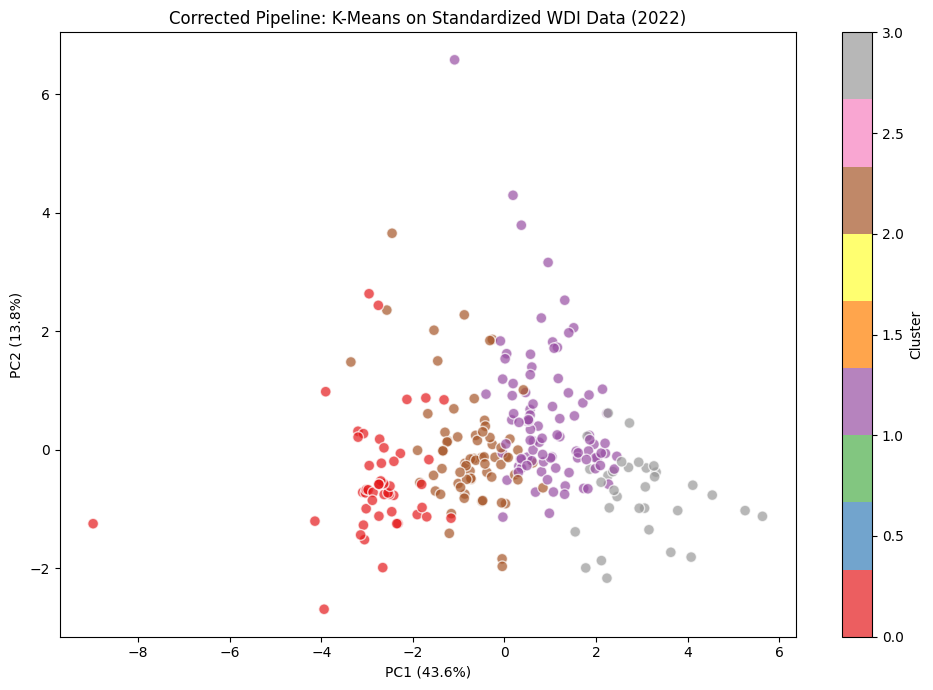

Silhouette score: 0.1669


In [7]:
# -----------------------------------------------------------
# Part 2: FIX — Corrected Pipeline
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

available_features = [col for col in feature_names if col in df.columns]
df_model = df[available_features].copy()

# Step 1: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# Step 2: K-Means with correct params
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init='auto',
    random_state=42
)
labels = kmeans.fit_predict(X_scaled)

# Step 3: PCA on standardized data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Visualize
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='Set1',
    alpha=0.7,
    edgecolors='white',
    s=60
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Corrected Pipeline: K-Means on Standardized WDI Data ({year})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Verification
sil = silhouette_score(X_scaled, labels)
print(f'Silhouette score: {sil:.4f}')

---

## Part 3: EXTEND — Customer Segmentation with Synthetic Data

Move beyond country-level data. In this section, you apply clustering to
a **customer segmentation** problem using synthetic behavioral data.
This mirrors how fintechs like Nubank (Chapter 22 opening hook) discover
customer archetypes from transaction patterns.

Then compare **PCA** and **UMAP** for dimensionality reduction.

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Generate synthetic customer data with 4 latent segments
# -----------------------------------------------------------

from sklearn.datasets import make_blobs

np.random.seed(42)

# Create 4 customer segments with 6 behavioral features
n_customers = 2000
segment_centers = [
    [50, 5, 80, 10, 2, 30],    # Budget-conscious: low spend, few txns, high app usage
    [200, 20, 40, 50, 8, 70],   # Power users: high spend, many txns
    [120, 12, 60, 30, 5, 50],   # Moderate users
    [300, 30, 20, 80, 12, 90],  # Premium: very high spend, low app engagement
]

X_cust, y_true = make_blobs(
    n_samples=n_customers,
    centers=segment_centers,
    cluster_std=[15, 25, 20, 20],
    random_state=42
)

cust_features = [
    'avg_monthly_spend', 'txn_frequency', 'app_sessions',
    'credit_utilization', 'products_held', 'digital_engagement'
]

cust_df = pd.DataFrame(X_cust, columns=cust_features)
cust_df['true_segment'] = y_true

print(f'Customers: {len(cust_df)}')
print(f'Features: {cust_features}')
print(f'True segments: {cust_df["true_segment"].value_counts().sort_index().to_dict()}')
print()
print(cust_df[cust_features].describe().round(1))

Customers: 2000
Features: ['avg_monthly_spend', 'txn_frequency', 'app_sessions', 'credit_utilization', 'products_held', 'digital_engagement']
True segments: {0: 500, 1: 500, 2: 500, 3: 500}

       avg_monthly_spend  txn_frequency  app_sessions  credit_utilization  \
count             2000.0         2000.0        2000.0              2000.0   
mean               167.4           16.7          50.2                41.7   
std                 94.6           22.2          30.4                33.0   
min                 10.5          -51.4         -58.4               -43.8   
25%                 80.3            1.1          26.9                15.4   
50%                155.2           15.7          52.3                38.8   
75%                251.2           31.5          74.8                67.0   
max                355.4           91.7         123.2               138.3   

       products_held  digital_engagement  
count         2000.0              2000.0  
mean             6.1         

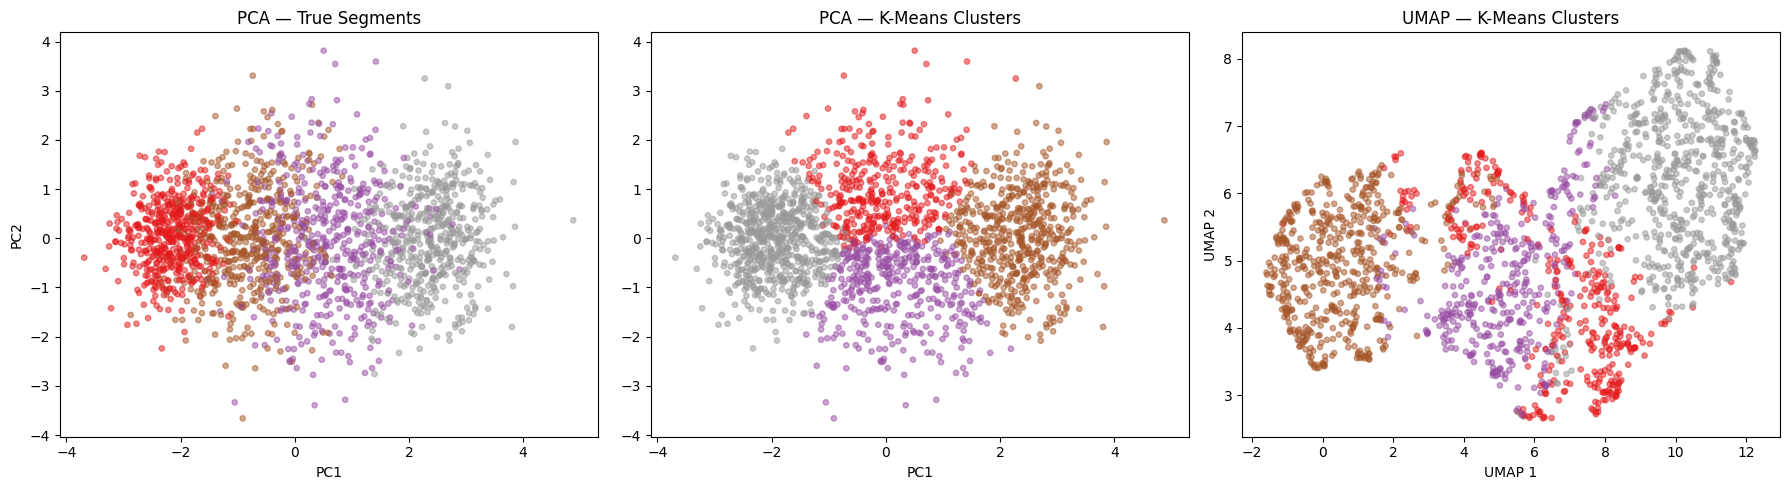

Silhouette score (K-Means K=4): 0.2387

Compare PCA vs UMAP: Which gives better visual separation?
UMAP preserves local structure better than PCA for non-linear data.


In [9]:
# -----------------------------------------------------------
# YOUR TASK — Cluster customers and compare PCA vs UMAP
# -----------------------------------------------------------

import umap

# Step 1: Standardize customer features
cust_scaler = StandardScaler()
X_cust_scaled = cust_scaler.fit_transform(cust_df[cust_features])

# Step 2: Fit K-Means with K=4 (we know the true number here)
km_cust = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
cust_df['kmeans_cluster'] = km_cust.fit_predict(X_cust_scaled)

# Step 3: PCA projection
pca_cust = PCA(n_components=2)
X_pca_cust = pca_cust.fit_transform(X_cust_scaled)

# Step 4: UMAP projection
# Fill in: n_neighbors controls local vs global structure
# n_neighbors=15 is a good default; min_dist=0.1 controls cluster tightness
reducer = umap.UMAP(
    n_neighbors=15,     # FILL IN: try 15
    min_dist=0.1,        # FILL IN: try 0.1
    n_components=2,
    random_state=42
)
X_umap_cust = reducer.fit_transform(X_cust_scaled)

# Step 5: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: PCA with TRUE labels
scatter1 = axes[0].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['true_segment'], cmap='Set1',
                           alpha=0.5, s=15)
axes[0].set_title('PCA — True Segments', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Panel 2: PCA with K-MEANS labels
scatter2 = axes[1].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[1].set_title('PCA — K-Means Clusters', fontsize=12)
axes[1].set_xlabel('PC1')

# Panel 3: UMAP with K-MEANS labels
scatter3 = axes[2].scatter(X_umap_cust[:, 0], X_umap_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[2].set_title('UMAP — K-Means Clusters', fontsize=12)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# Silhouette comparison
sil_kmeans = silhouette_score(X_cust_scaled, cust_df['kmeans_cluster'])
print(f'Silhouette score (K-Means K=4): {sil_kmeans:.4f}')
print()
print('Compare PCA vs UMAP: Which gives better visual separation?')
print('UMAP preserves local structure better than PCA for non-linear data.')

PCA vs UMAP Comparison:

From the plots, **UMAP gives better visual separation than PCA**. PCA is a **linear method**, so it projects the data onto straight directions. Because of this, some clusters overlap and are not clearly separated in the PCA plots. UMAP is a **nonlinear method** that preserves local structure. In the UMAP plot, the clusters are more clearly separated and easier to distinguish. In this synthetic dataset, both methods work reasonably well because the data is relatively simple. However, UMAP still shows clearer boundaries between segments. In this case, UMAP provides better cluster visualization, while PCA is simpler but may mix clusters together.

---

## Part 4: Module Output — `clustering_utils.py`

Write a reusable Python module with three functions for clustering pipelines.
This is a **portfolio artifact** that demonstrates production-grade unsupervised learning.

### Requirements

```python
# clustering_utils.py

def run_kmeans_pipeline(df, features, k, random_state=42):
    """End-to-end K-Means pipeline: standardize, fit, return labels + metadata."""
    ...

def evaluate_k_range(X, k_range, random_state=42):
    """Compute WCSS and silhouette scores for a range of K values."""
    ...

def plot_pca_clusters(X, labels, feature_names):
    """PCA 2D scatter with cluster coloring + loadings annotation."""
    ...
```

In [10]:
# -----------------------------------------------------------
# YOUR TASK — Write clustering_utils.py
# Implement the three functions below
# -----------------------------------------------------------

# %%writefile clustering_utils.py
"""
clustering_utils.py — Reusable Clustering Pipeline Module

Functions for standardized K-Means clustering, K evaluation,
and PCA visualization.

Author: Guanyu Qu
Course: ECON 5200, Lab 22
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from typing import List, Dict


def run_kmeans_pipeline(
    df: pd.DataFrame,
    features: List[str],
    k: int,
    random_state: int = 42
) -> Dict:
    """End-to-end K-Means pipeline."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=random_state
    )
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    return {
        'labels': labels,
        'scaler': scaler,
        'model': kmeans,
        'X_scaled': X_scaled,
        'silhouette': sil,
        'inertia': kmeans.inertia_
    }


def evaluate_k_range(
    X: np.ndarray,
    k_range: range,
    random_state: int = 42
) -> pd.DataFrame:
    """Evaluate clustering quality across a range of K values."""
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++',
                    n_init='auto', random_state=random_state)
        labels = km.fit_predict(X)
        results.append({
            'k': k,
            'wcss': km.inertia_,
            'silhouette': silhouette_score(X, labels)
        })
    return pd.DataFrame(results)


def plot_pca_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: List[str]
) -> None:
    """PCA 2D scatter plot with cluster coloring."""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=labels, cmap='Set1',
        alpha=0.7, edgecolors='white', s=60
    )
    ax.set_xlabel(
        f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
        fontsize=12
    )
    ax.set_ylabel(
        f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
        fontsize=12
    )
    ax.set_title('K-Means Clusters (PCA Projection)', fontsize=13)
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.show()

    # Print top PC1 loadings
    loadings = pd.Series(pca.components_[0], index=feature_names)
    print('Top PC1 loadings:')
    for feat in loadings.abs().nlargest(3).index:
        print(f'  {feat}: {loadings[feat]:.4f}')

---

## Challenge: Hierarchical Clustering Comparison

K-Means assumes spherical clusters and requires you to specify K upfront.
**Agglomerative hierarchical clustering** builds a tree (dendrogram) of
nested clusters and lets you choose K after inspecting the tree.

Compare K-Means and Agglomerative clustering on the WDI data:
1. Fit `AgglomerativeClustering(n_clusters=4)` on the standardized WDI data
2. Plot the dendrogram using `scipy.cluster.hierarchy`
3. Compare cluster assignments with K-Means — do they agree?

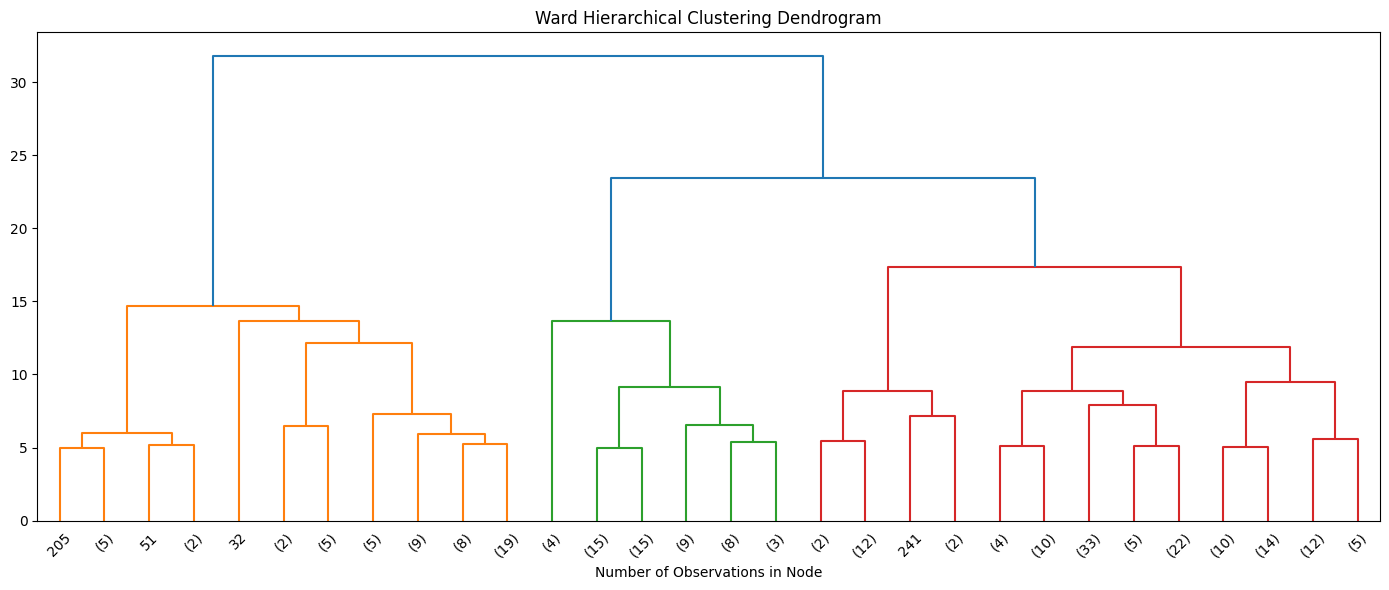

Agglom.   0   1   2   3
K-Means                
0        44   3   0   2
1         1  52  26  15
2        13  56   0   0
3         0   4  28   0
K-Means silhouette:       0.1669
Agglomerative silhouette: 0.2103


In [11]:
# -----------------------------------------------------------
# CHALLENGE — Hierarchical clustering + dendrogram
# -----------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Step 1: Fit agglomerative clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)


# Step 2: Plot dendrogram
linkage_matrix = linkage(X_scaled, method='ward')
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, ax=ax)
ax.set_title('Ward Hierarchical Clustering Dendrogram')
ax.set_xlabel('Number of Observations in Node')
plt.tight_layout()
plt.show()


# Step 3: Cross-tabulate K-Means vs Agglomerative labels
ct = pd.crosstab(labels, agg_labels, rownames=['K-Means'], colnames=['Agglom.'])
print(ct)


# Step 4: Compare silhouette scores
sil_km = silhouette_score(X_scaled, labels)
sil_agg = silhouette_score(X_scaled, agg_labels)
print(f'K-Means silhouette:       {sil_km:.4f}')
print(f'Agglomerative silhouette: {sil_agg:.4f}')


K-Means vs Agglomerative Clustering Comparison:

The cluster assignments are **partially similar but not identical**.

From the cross-tabulation, some clusters align well (for example, K-Means cluster 0 mostly matches Agglomerative cluster 0). However, other clusters are split or mixed across multiple groups, showing disagreement.

The silhouette scores also differ: K-Means: 0.1669, Agglomerative: 0.2103  

This indicates that **Agglomerative clustering performs slightly better** on this dataset. Overall, the two methods show some agreement, but not perfectly. Agglomerative clustering captures the structure a bit better, while K-Means is more restrictive due to its assumption of spherical clusters.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken K-Means pipeline (missing standardization,
  wrong parameter name, PCA before scaling, no random_state)
* Built a corrected pipeline: StandardScaler -> K-Means -> PCA visualization
* Applied clustering to customer segmentation with synthetic behavioral data
* Compared PCA vs UMAP for dimensionality reduction
* Built a reusable clustering_utils.py module with run_kmeans_pipeline(),
  evaluate_k_range(), and plot_pca_clusters()
* Key finding: [FILL IN — what K was optimal? How did PCA vs UMAP compare?]

**Please write a README.md entry including:**
1. Project Title: Unsupervised Learning — Clustering & Dimensionality Reduction
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA, UMAP & Module"
git push origin main
```

Submit your GitHub repo link on Canvas.